## Odds ratio analysis of gene loss and duplication

Testing whether the odds that genes in an orthogroup are missing, in single copy, or in multiple copies differs significantly between orb-weavers and non-orb-weavers

#### import modules

In [ ]:
import os
import sys
import pandas as pd
from importlib import reload


# Ensure the src directory is in the Python path
scripts = os.path.abspath('')
src_path = os.path.abspath(os.path.join(scripts, '..', 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)

# Define paths to data and results directories
data = os.path.join(scripts, "..", "data")
results = os.path.join(scripts, "..", "results")


# Import the odds_ratio_test
import odds_ratio_test as ort

<module 'odds_ratio_test' from '/Users/calvin/orb-selection/src/odds_ratio_test.py'>

In [56]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### specify input files

In [57]:
genecount_csv = f"{data}/N5.GeneCount.tsv"
orb_list_filename = f"{data}/orbweavers-list.txt"
hog_node_genes_tsv = f"{data}/N5.tsv"

Testing for loss of genes first, using occupancy threshold of 75 (same as HyPhy analysis)

Also using a maximum occupancy of N-3 = 95 so there can be some meaningful comparison of loss between the test groups.

In [58]:
loss_results_dir = f"{results}/loss-test"

Testing skew, mean, and standard deviation, first using a left-tailed alternative hypothesis

98 species total, 44 foreground, 54 background

LAUNCHING BOOTSTRAPPING TEST

** Maximum occupancy set to 95 **

** Minimum occupancy set to 75 **

Counting bootstrapped distributions in which statistics
derived from randomly assigned test groups are SMALLER
than the true distribution's statistics (left-tailed)...



100%|██████████| 10000/10000 [01:05<00:00, 153.06it/s]



Bootstrapping counter for MEAN: 0
Bootstrapping counter for STD DEV: 10000
Bootstrapping counter for SKEW: 8606

Filtering log odds ratio results df for occupancy >= 75, <= 95
and log odds ratio threshold [-1.71517558  1.71753257]

Filtering for presence of Uloborus_diversus

*********************** RESULTS ***********************

Bootstrapping test with 10000 repetitions for loss (left-tailed)
with minimum occupancy *75* and maximum occupancy *95* 
Analysis run on 2025-07-21 at 18:14:33
Foreground list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 2627
Total species: 98
Foreground count: 44
Background count: 54
True mean: -0.6300388762633876
True standard deviation: 1.5374700980875577
True skew: 0.14789325395694103

** BOO

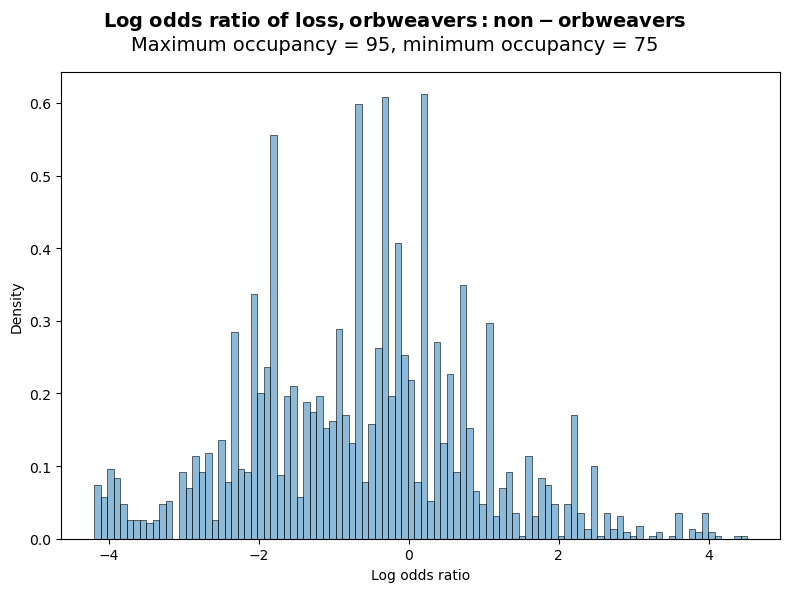

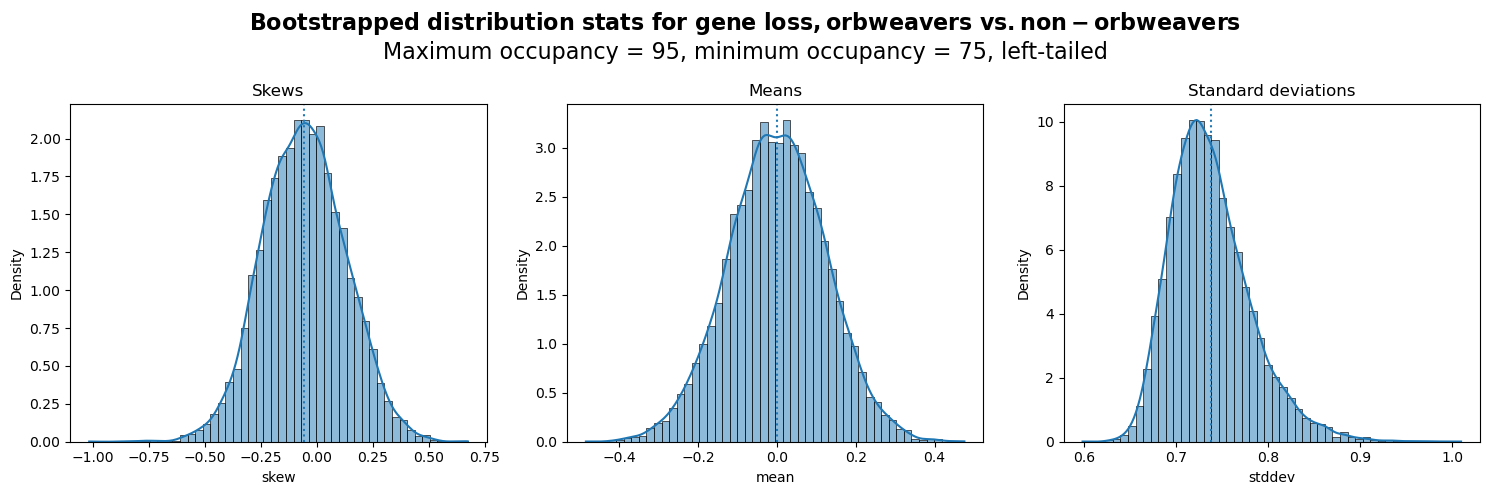

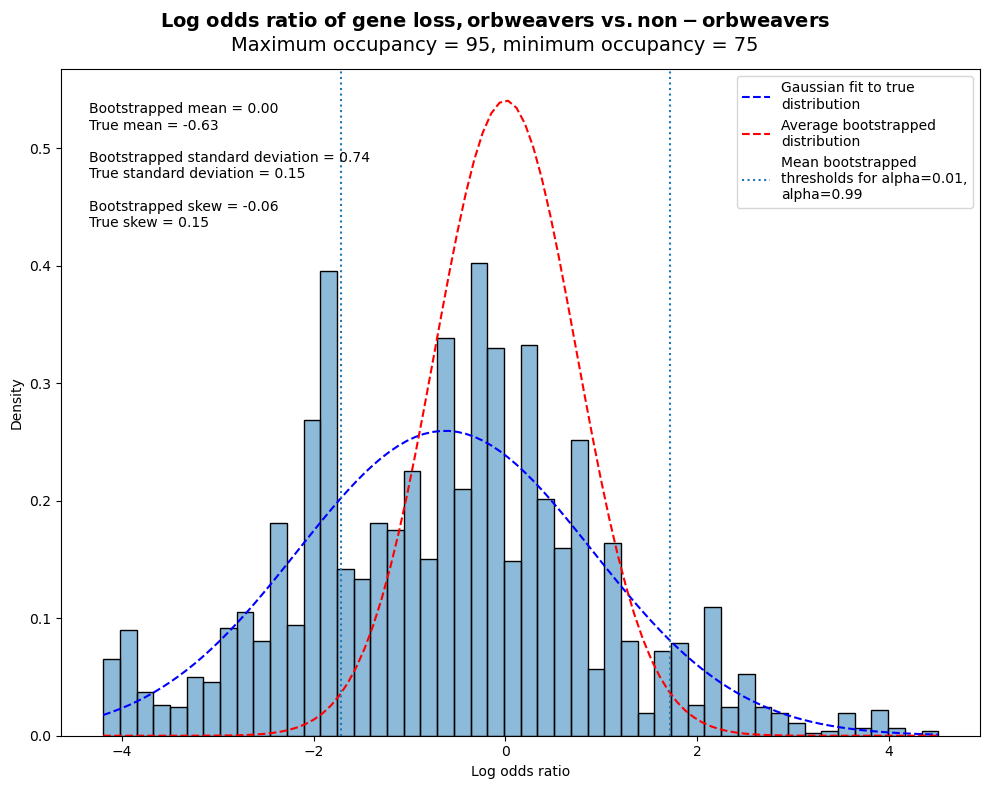

In [59]:
loss_lt_75_95 = ort.odds_ratio_test(
    orb_list_filename,
    hog_node_genes_tsv,
    "loss",
    genecount_csv=genecount_csv,
    occupancy_threshold=75,
    max_occ=95, 
    alpha=0.01,
    alternative="less",
    species_of_interest="Uloborus_diversus",
    results_dir=loss_results_dir,
    fg_name='orbweavers',
    bg_name='non-orbweavers'
)

Same test but right-tailed (two-tailed is not possible with the bootstrapping analysis)

98 species total, 44 foreground, 54 background

LAUNCHING BOOTSTRAPPING TEST

** Maximum occupancy set to 95 **

** Minimum occupancy set to 75 **

Counting bootstrapped distributions in which statistics
derived from randomly assigned test groups EXCEED
the true distribution's statistics (right-tailed)...



100%|██████████| 10000/10000 [01:21<00:00, 122.58it/s]



Bootstrapping counter for MEAN: 10000
Bootstrapping counter for STD DEV: 0
Bootstrapping counter for SKEW: 1411

Filtering log odds ratio results df for occupancy >= 75, <= 95
and log odds ratio threshold [-1.71698561  1.72041867]

Filtering for presence of Uloborus_diversus

*********************** RESULTS ***********************

Bootstrapping test with 10000 repetitions for loss (right-tailed)
with minimum occupancy *75* and maximum occupancy *95* 
Analysis run on 2025-07-21 at 18:15:40
Foreground list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 2627
Total species: 98
Foreground count: 44
Background count: 54
True mean: -0.6300388762633876
True standard deviation: 1.5374700980875577
True skew: 0.14789325395694103

** BO

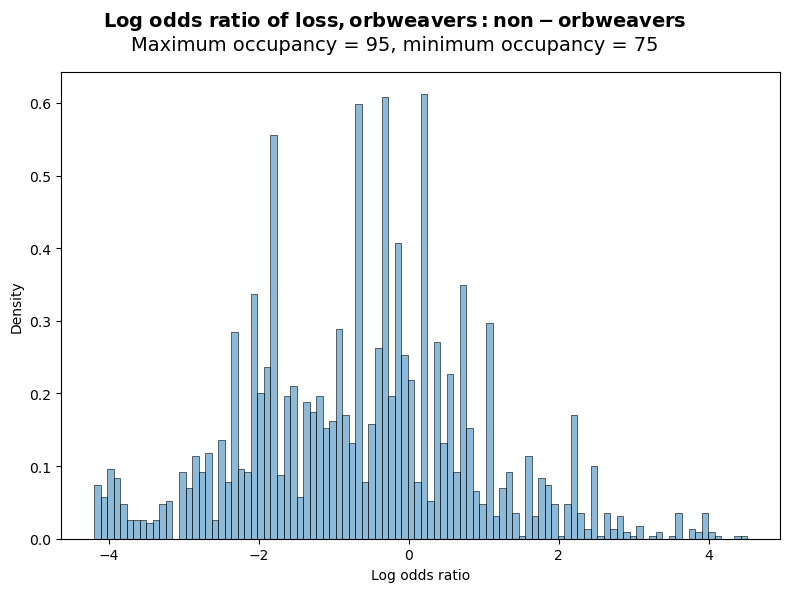

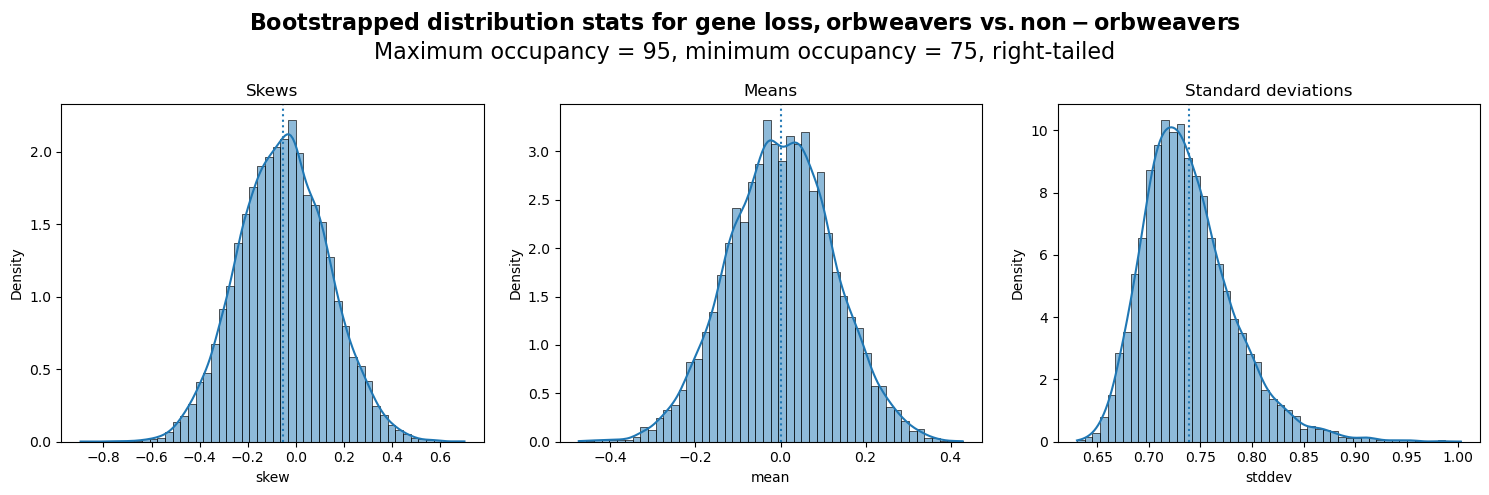

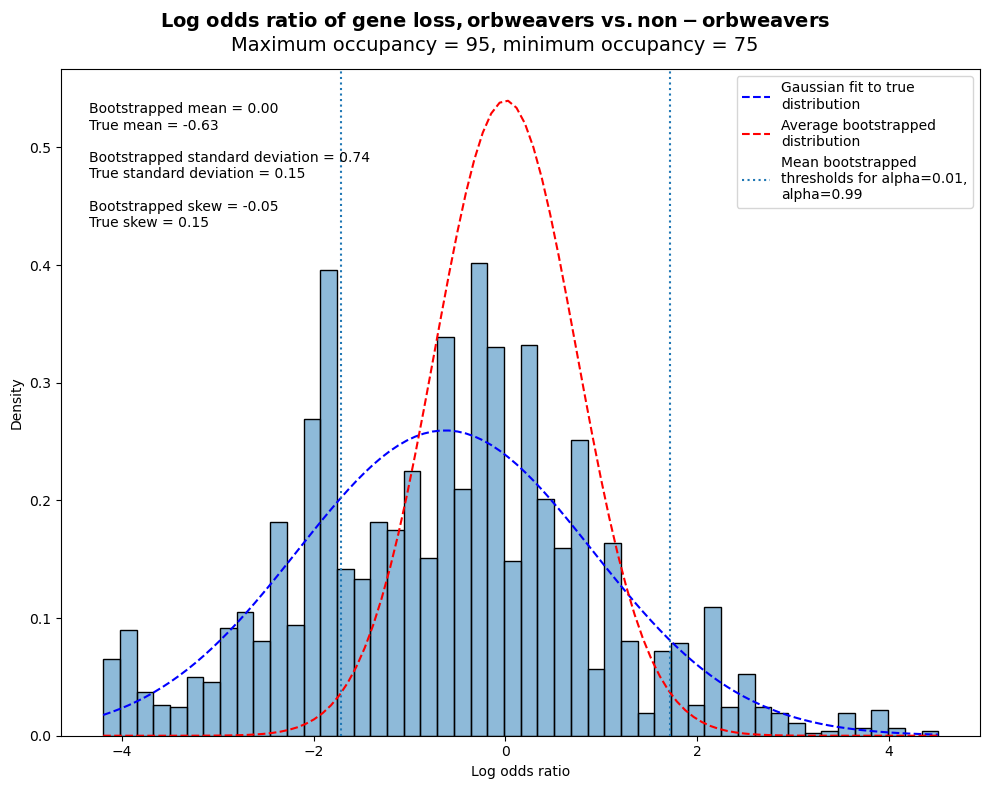

In [60]:
loss_rt_75_95 = ort.odds_ratio_test(
    orb_list_filename,
    hog_node_genes_tsv,
    "loss",
    genecount_csv=genecount_csv,
    occupancy_threshold=75,
    max_occ=95, 
    alpha=0.01,
    alternative="greater",
    species_of_interest="Uloborus_diversus",
    results_dir=loss_results_dir,
    fg_name='orbweavers',
    bg_name='non-orbweavers'
)

Testing for duplication of genes, using minimum occupancy threshold of 75, no max occupancy.

In [61]:
dup_results_dir = f"{results}/duplication-test"

98 species total, 44 foreground, 54 background

LAUNCHING BOOTSTRAPPING TEST

** Minimum occupancy set to 75 **

Counting bootstrapped distributions in which statistics
derived from randomly assigned test groups are SMALLER
than the true distribution's statistics (left-tailed)...



100%|██████████| 10000/10000 [01:14<00:00, 133.91it/s]



Bootstrapping counter for MEAN: 1765
Bootstrapping counter for STD DEV: 10000
Bootstrapping counter for SKEW: 8800

Filtering log odds ratio results df for occupancy >= 75, <= 98
and log odds ratio threshold [-1.45386314  1.45616858]

Filtering for presence of Uloborus_diversus

*********************** RESULTS ***********************

Bootstrapping test with 10000 repetitions for duplication (left-tailed)
with minimum occupancy *75* and maximum occupancy *no* 
Analysis run on 2025-07-21 at 18:17:05
Foreground list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 5233
Total species: 98
Foreground count: 44
Background count: 54
True mean: -0.04746996232571979
True standard deviation: 0.8929220790292889
True skew: 0.05944950339281

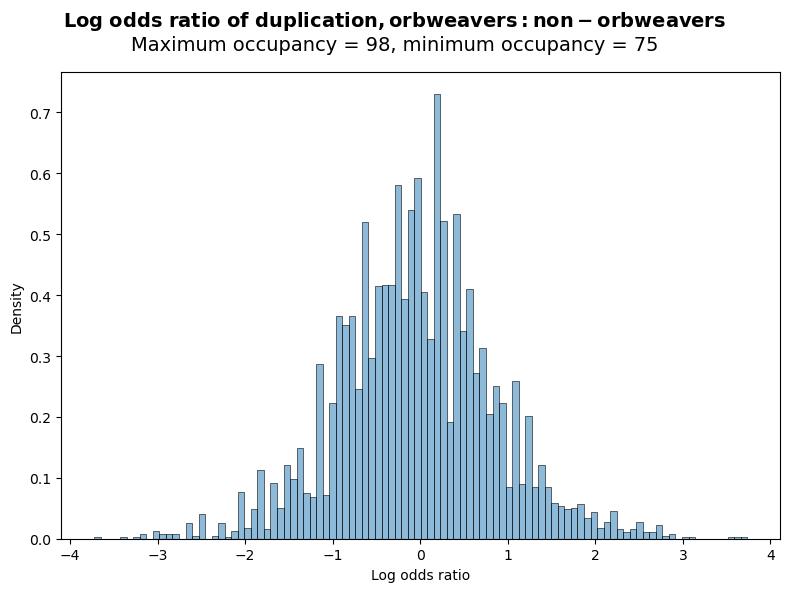

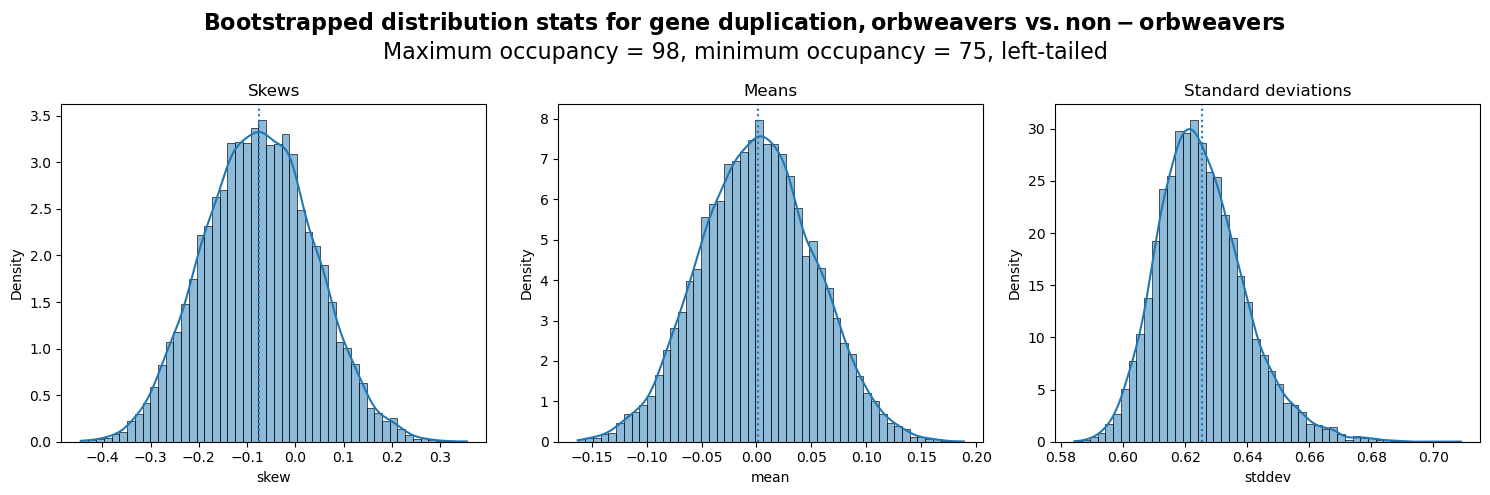

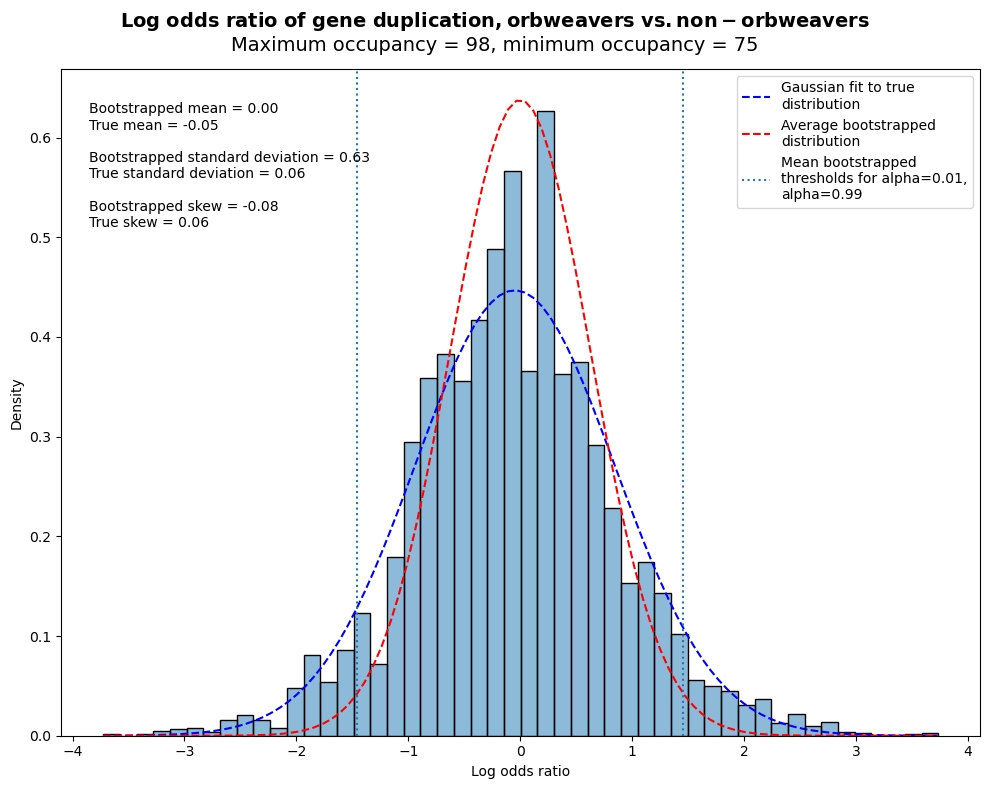

In [62]:
dup_lt_75_98 = ort.odds_ratio_test(
    orb_list_filename,
    hog_node_genes_tsv,
    "duplication",
    genecount_csv=genecount_csv,
    occupancy_threshold=75,
    alpha=0.01,
    alternative="less",
    species_of_interest="Uloborus_diversus",
    results_dir=dup_results_dir,
    fg_name='orbweavers',
    bg_name='non-orbweavers'
)

98 species total, 44 foreground, 54 background

LAUNCHING BOOTSTRAPPING TEST

** Minimum occupancy set to 75 **

Counting bootstrapped distributions in which statistics
derived from randomly assigned test groups EXCEED
the true distribution's statistics (right-tailed)...



100%|██████████| 10000/10000 [01:16<00:00, 130.14it/s]



Bootstrapping counter for MEAN: 8211
Bootstrapping counter for STD DEV: 0
Bootstrapping counter for SKEW: 1205

Filtering log odds ratio results df for occupancy >= 75, <= 98
and log odds ratio threshold [-1.45488713  1.45565167]

Filtering for presence of Uloborus_diversus

*********************** RESULTS ***********************

Bootstrapping test with 10000 repetitions for duplication (right-tailed)
with minimum occupancy *75* and maximum occupancy *no* 
Analysis run on 2025-07-21 at 18:18:22
Foreground list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 5233
Total species: 98
Foreground count: 44
Background count: 54
True mean: -0.04746996232571979
True standard deviation: 0.8929220790292889
True skew: 0.05944950339281756

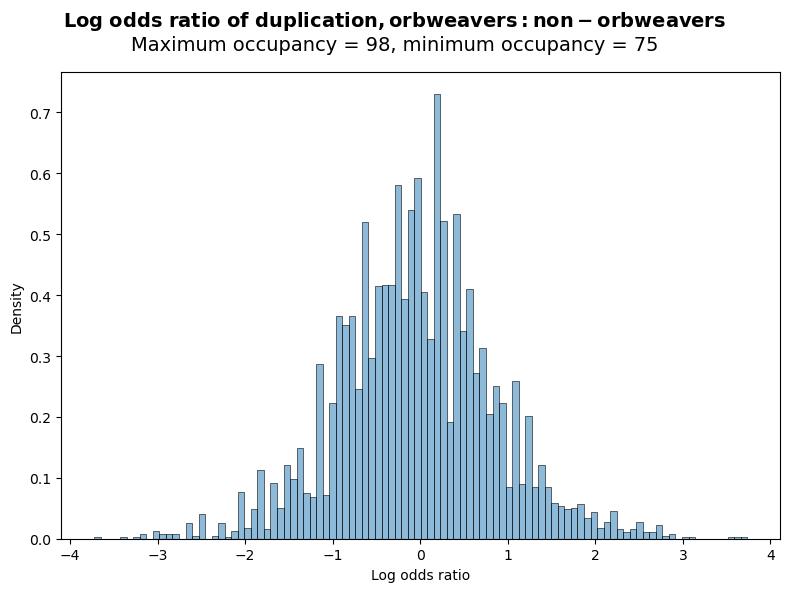

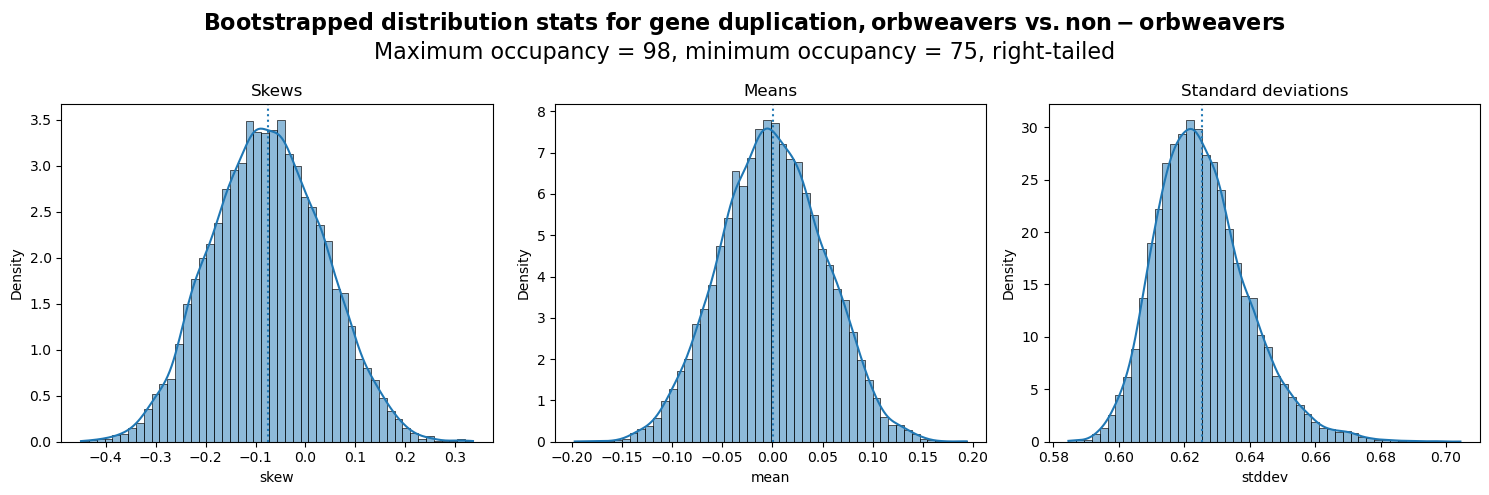

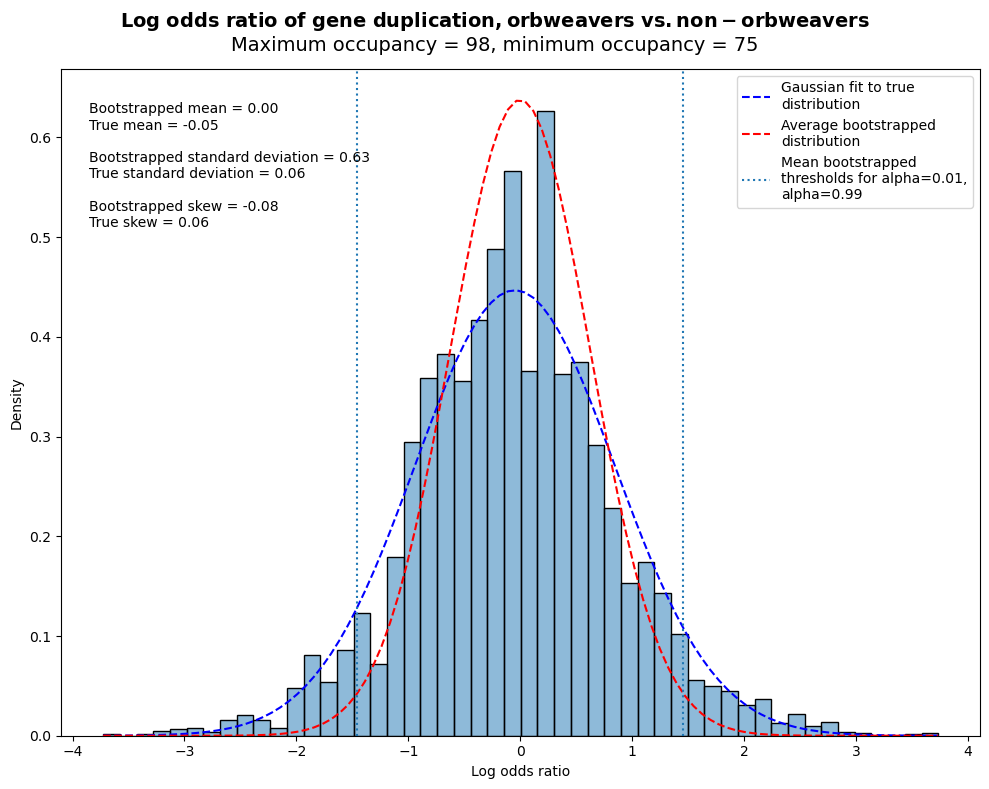

In [63]:
dup_rt_75_98 = ort.odds_ratio_test(
    orb_list_filename,
    hog_node_genes_tsv,
    "duplication",
    genecount_csv=genecount_csv,
    occupancy_threshold=75,
    alpha=0.01,
    alternative="greater",
    species_of_interest="Uloborus_diversus",
    results_dir=dup_results_dir,
    fg_name='orbweavers',
    bg_name='non-orbweavers'
)

Repeat all 4 tests with occupancy threshold = 50

In [64]:
import itertools
tests=list(itertools.product(["loss","duplication"],["less","greater"]))

98 species total, 44 foreground, 54 background

LAUNCHING BOOTSTRAPPING TEST

** Minimum occupancy set to 50 **

Counting bootstrapped distributions in which statistics
derived from randomly assigned test groups are SMALLER
than the true distribution's statistics (left-tailed)...



100%|██████████| 10000/10000 [01:20<00:00, 124.22it/s]



Bootstrapping counter for MEAN: 0
Bootstrapping counter for STD DEV: 10000
Bootstrapping counter for SKEW: 1635

Filtering log odds ratio results df for occupancy >= 50, <= 98
and log odds ratio threshold [-1.49971246  1.59653975]

Filtering for presence of Uloborus_diversus

*********************** RESULTS ***********************

Bootstrapping test with 10000 repetitions for loss (left-tailed)
with minimum occupancy *50* and maximum occupancy *no* 
Analysis run on 2025-07-21 at 18:19:41
Foreground list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 7875
Total species: 98
Foreground count: 44
Background count: 54
True mean: -0.4366373600248551
True standard deviation: 1.3756410093824312
True skew: -0.1194376965592425

** BOO

100%|██████████| 10000/10000 [01:21<00:00, 123.36it/s]



Bootstrapping counter for MEAN: 10000
Bootstrapping counter for STD DEV: 0
Bootstrapping counter for SKEW: 8428

Filtering log odds ratio results df for occupancy >= 50, <= 98
and log odds ratio threshold [-1.50179799  1.59448127]

Filtering for presence of Uloborus_diversus

*********************** RESULTS ***********************

Bootstrapping test with 10000 repetitions for loss (right-tailed)
with minimum occupancy *50* and maximum occupancy *no* 
Analysis run on 2025-07-21 at 18:21:04
Foreground list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 7875
Total species: 98
Foreground count: 44
Background count: 54
True mean: -0.4366373600248551
True standard deviation: 1.3756410093824312
True skew: -0.1194376965592425

** BO

100%|██████████| 10000/10000 [01:17<00:00, 128.23it/s]



Bootstrapping counter for MEAN: 6579
Bootstrapping counter for STD DEV: 10000
Bootstrapping counter for SKEW: 8882

Filtering log odds ratio results df for occupancy >= 50, <= 98
and log odds ratio threshold [-1.52865956  1.53497233]

Filtering for presence of Uloborus_diversus

*********************** RESULTS ***********************

Bootstrapping test with 10000 repetitions for duplication (left-tailed)
with minimum occupancy *50* and maximum occupancy *no* 
Analysis run on 2025-07-21 at 18:22:27
Foreground list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 7875
Total species: 98
Foreground count: 44
Background count: 54
True mean: 0.025141820982255005
True standard deviation: 0.9948985446732754
True skew: 0.07558266034746

100%|██████████| 10000/10000 [01:21<00:00, 122.81it/s]



Bootstrapping counter for MEAN: 3389
Bootstrapping counter for STD DEV: 0
Bootstrapping counter for SKEW: 1107

Filtering log odds ratio results df for occupancy >= 50, <= 98
and log odds ratio threshold [-1.5294549   1.53445194]

Filtering for presence of Uloborus_diversus

*********************** RESULTS ***********************

Bootstrapping test with 10000 repetitions for duplication (right-tailed)
with minimum occupancy *50* and maximum occupancy *no* 
Analysis run on 2025-07-21 at 18:23:47
Foreground list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 7875
Total species: 98
Foreground count: 44
Background count: 54
True mean: 0.025141820982255005
True standard deviation: 0.9948985446732754
True skew: 0.07558266034746924

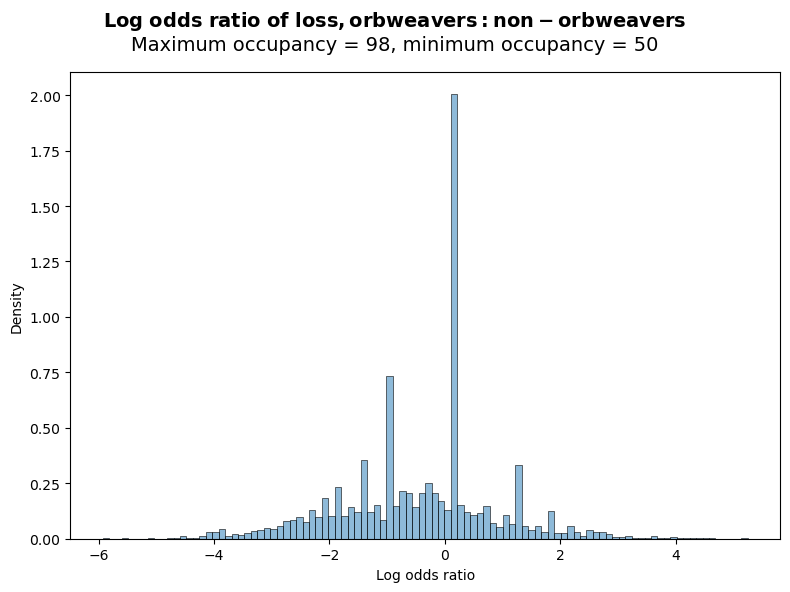

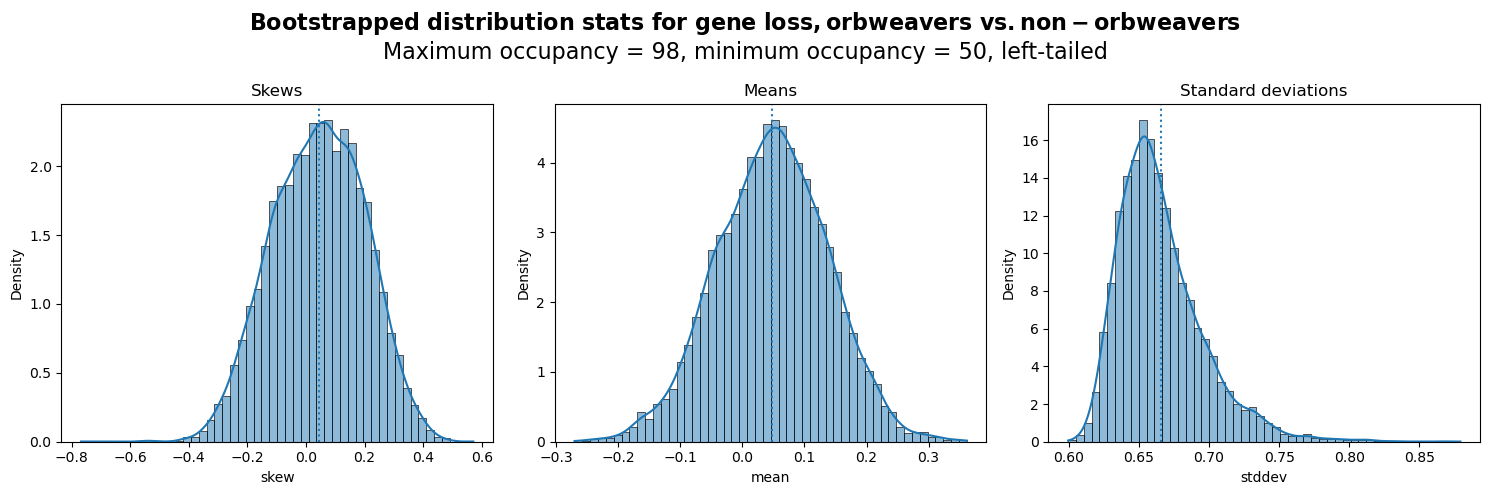

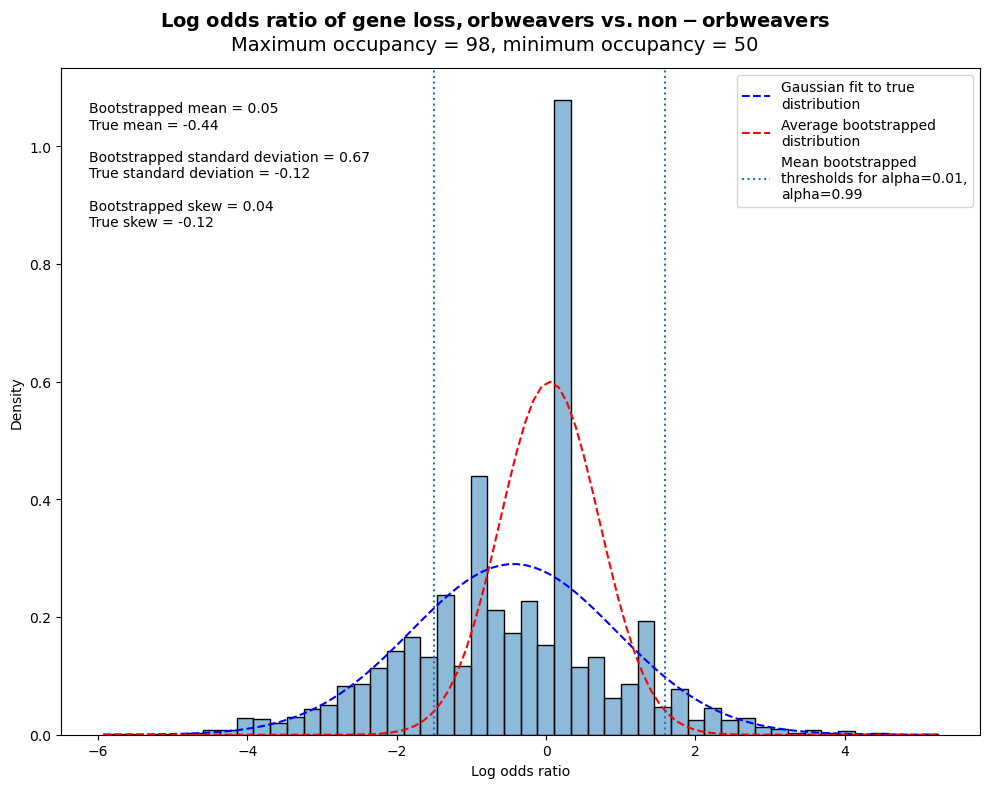

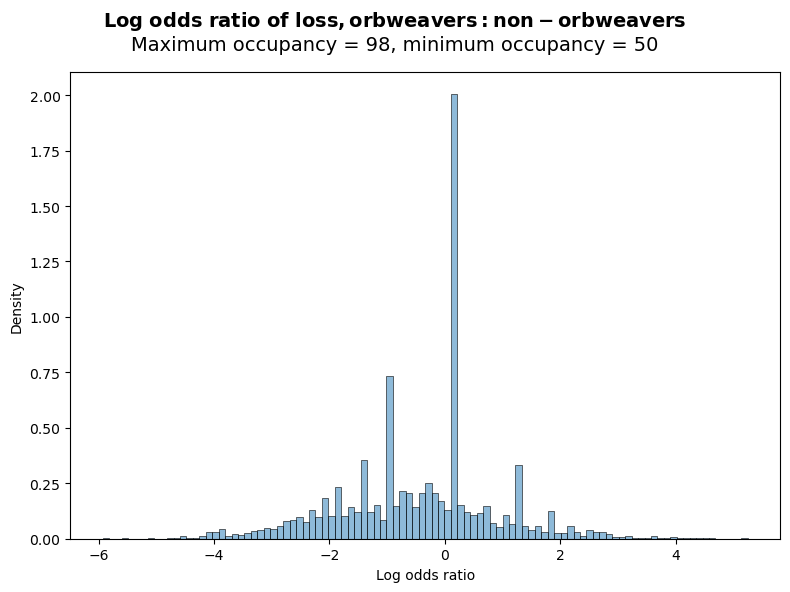

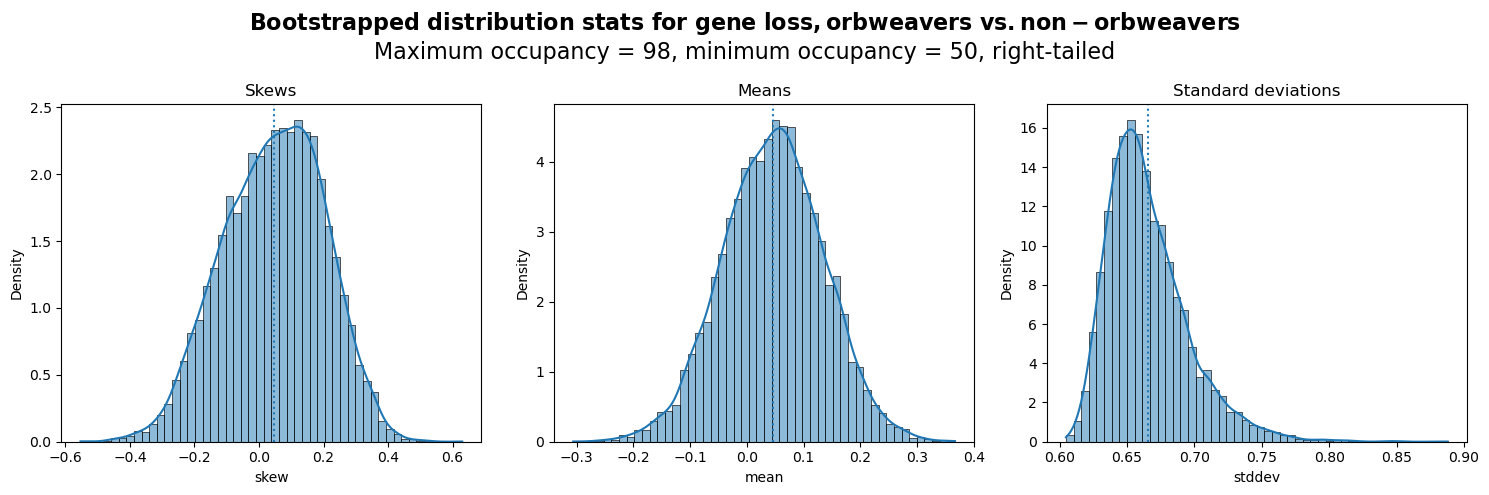

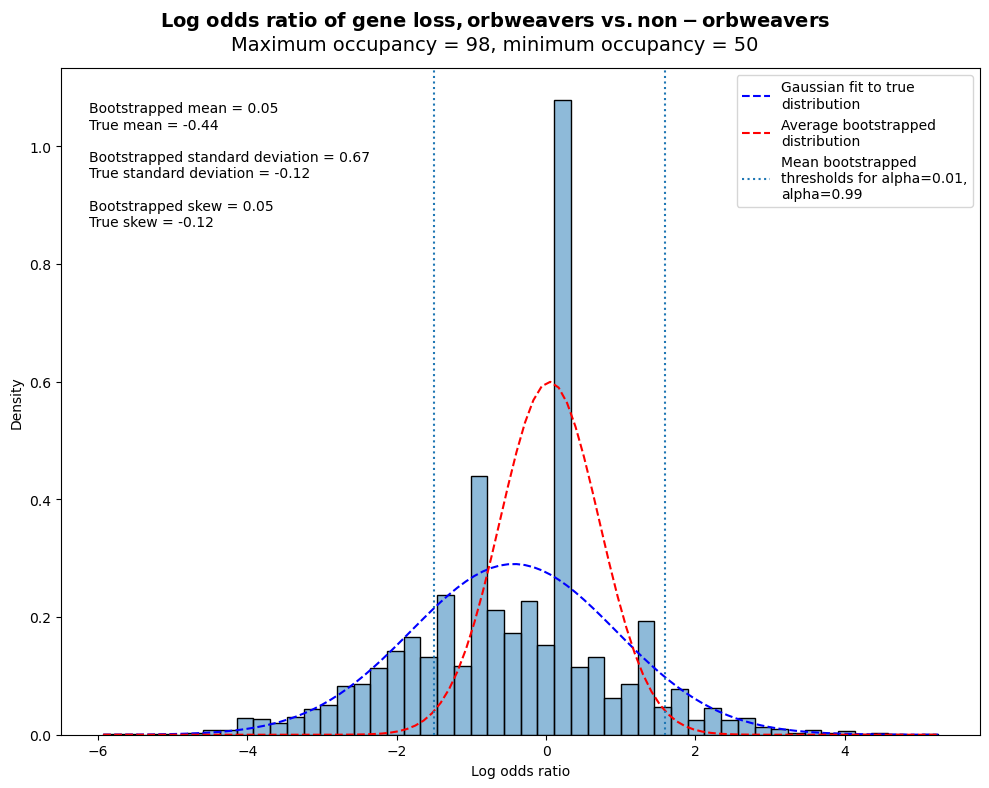

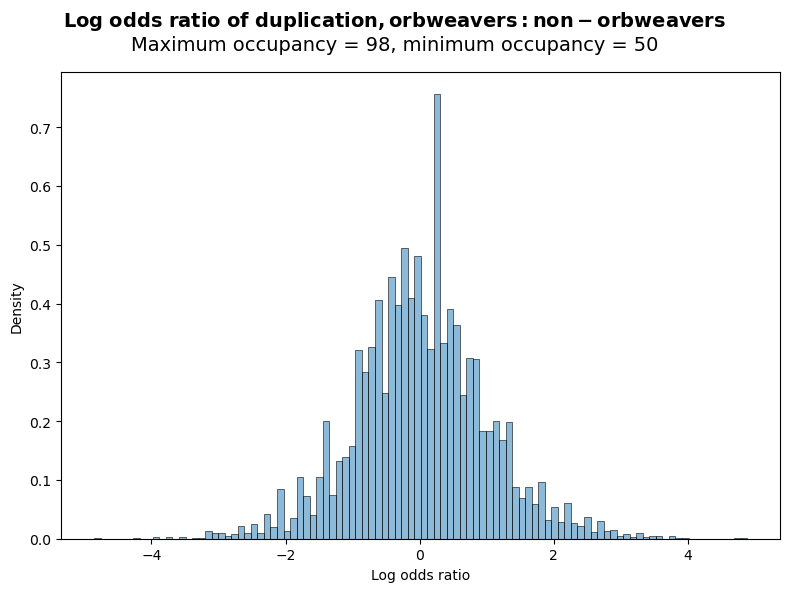

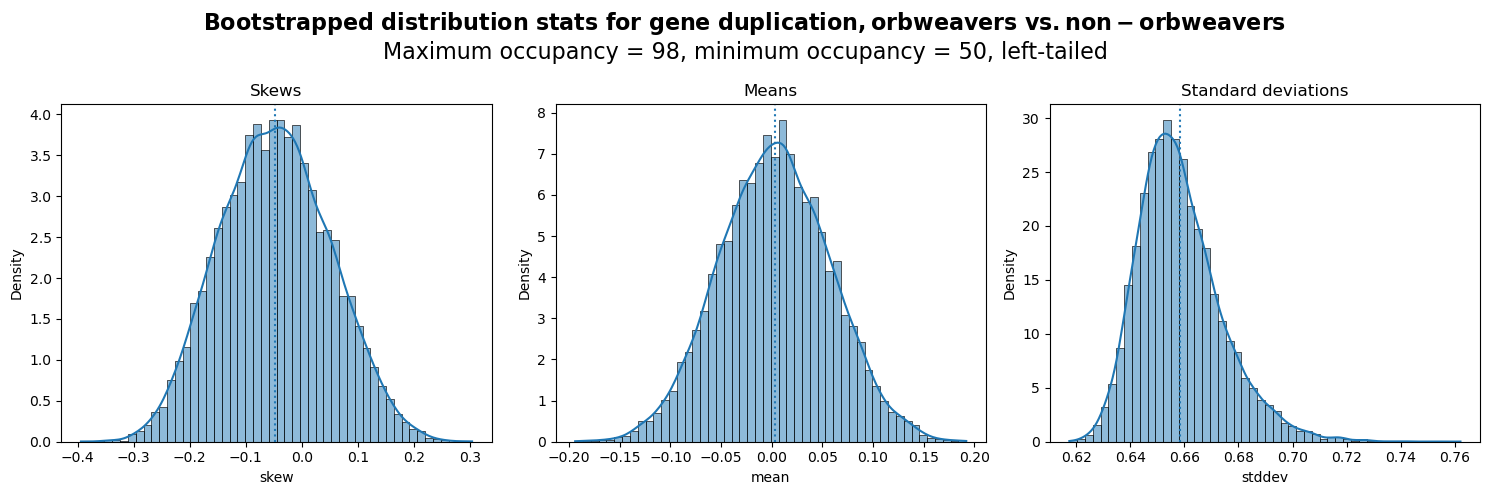

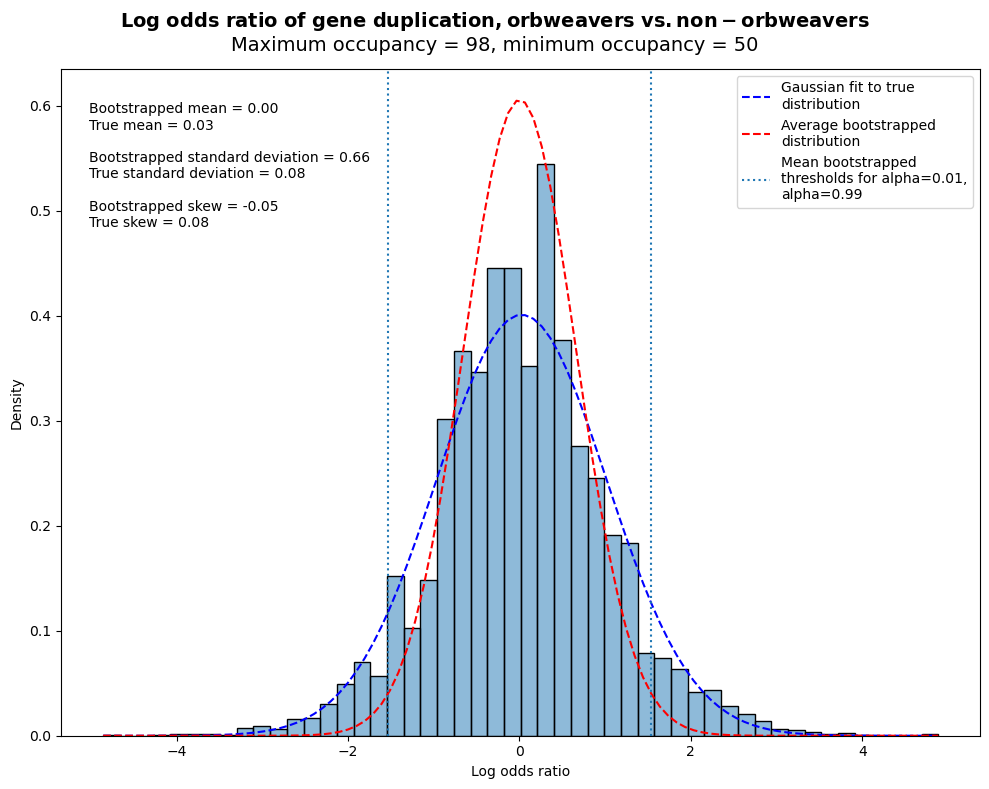

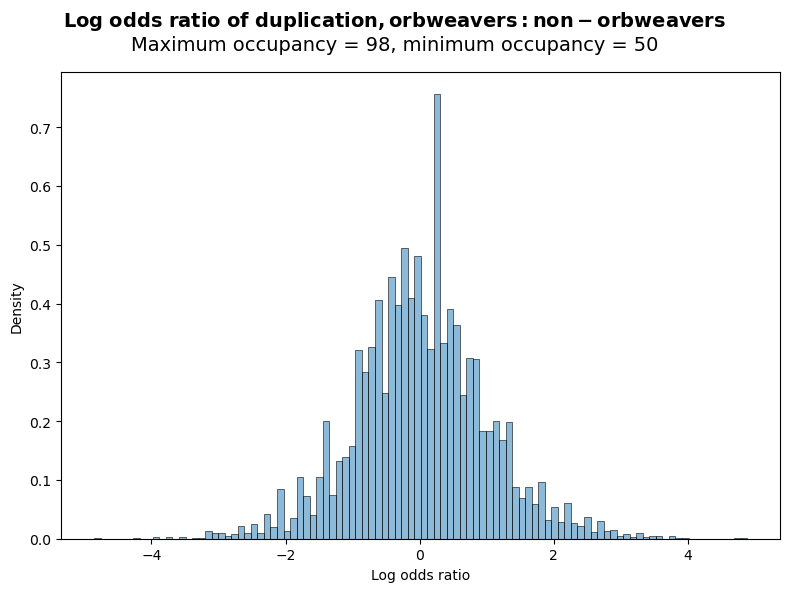

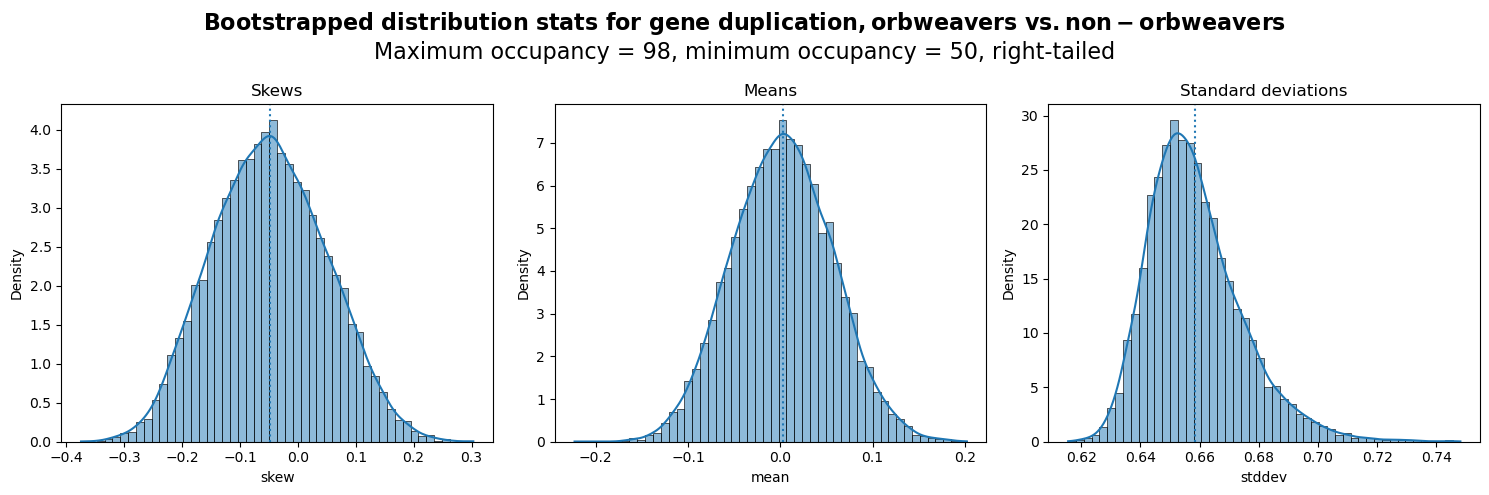

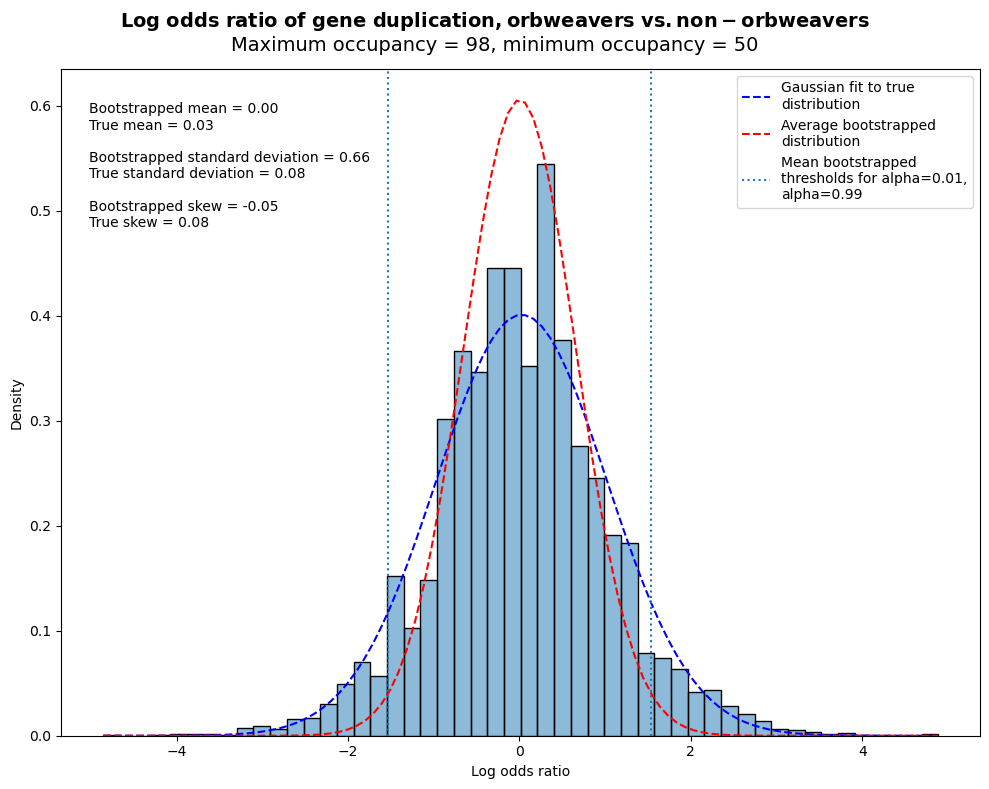

In [65]:
for test in tests:
    ort.odds_ratio_test(
        orb_list_filename,
        hog_node_genes_tsv,
        test=test[0],
        genecount_csv=genecount_csv,
        occupancy_threshold=50,
        alpha=0.01,
        alternative=test[1],
        species_of_interest="Uloborus_diversus",
        results_dir='/Users/calvin/orb-selection/results/ort_occ_50',
        fg_name='orbweavers',
        bg_name='non-orbweavers'
    )

Move this next stuff to a new script.

In [ ]:
import id_converter

In [ ]:
def get_LOCs(BsTestResults):
    
    df = BsTestResults.results_fltrd_df
    tsv = BsTestResults.true_odds.hog_node_genes_tsv

    merged_df = id_converter.main(df, tsv)
   
    locs_list = merged_df["LOC"].dropna().unique()

    return locs_list

In [ ]:
import pickle

In [ ]:
def load_pickle_file(fname):
        """
        Loads a previously saved the bootstrap results pickle file.
        """

        with open(fname, 'rb') as file:
            pickle.load(file)